In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import Flickr8k
import torchvision.transforms as transforms

import tiktoken as tk
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import pprint
import zipfile
import os
import textwrap
import io
from tqdm import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
def plot_training_results(train_losses, val_losses, eval_interval, title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses)) + 1) * eval_interval

    plt.plot(steps, train_losses, label='Train', alpha=0.5)
    plt.plot(steps, val_losses, label='Val')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def calc_batch_loss(model, batch, device):
  imgs, tokens = batch
  batch_size, _, _, _ = imgs.shape
  imgs = imgs.to(device)
  tokens = {k: v.to(device) for k, v in tokens.items()}
  logits = model(imgs, tokens) # (batch_size, batch_size)
  labels = torch.arange(0, batch_size, device=device)
  loss1 = nn.functional.cross_entropy(logits, labels) # across rows
  loss2 = nn.functional.cross_entropy(logits.T, labels) # across cols
  loss = (loss1 + loss2) / 2

  preds = torch.argmax(logits, dim=-1)
  r_at_1 = (preds == labels).float().sum() # will take mean in evaluate

  return loss, r_at_1

In [5]:
def evaluate(loader, model, device, max_batch=5):
  total_loss = 0
  total_samples = 0
  total_r_at_1 = 0
  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, batch in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, r_at_1 = calc_batch_loss(model, batch, device)
      total_loss += loss.item()
      total_r_at_1 += r_at_1.item()
      total_samples += batch[0].shape[0]
    else:
      break

  return total_loss/max_batch, total_r_at_1/total_samples

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Dataset Loading**

In [7]:
zip_path = "/content/drive/My Drive/Flickr8k.zip"          # path to zip file
extract_path = "/content/drive/My Drive/Flickr8k"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.image_dir = image_dir
        self.transform = transform

        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i==0:
                  continue

                line = line.strip()

                # split only on first comma
                img, caption = line.split(',', 1)

                # remove surrounding quotes
                caption = caption.strip().strip('"')

                # keep only first caption per image
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        # convert dict → list for indexing
        self.image_files = list(self.image_caption_map.keys())

        # reproducible shuffle
        np.random.seed(42)
        np.random.shuffle(self.image_files)

        # split index
        split_idx = int(len(self.image_files) * split)

        if mode == "train":
            self.image_files = self.image_files[:split_idx]
        elif mode == "val":
            self.image_files = self.image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        caption = self.image_caption_map[img_name]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, caption

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

val_dataset = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

In [ ]:
len(train_dataset), len(val_dataset)

(6472, 1619)

In [ ]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
train_dataset[0][0].min(), train_dataset[0][0].max(), train_dataset[0][0].unique().numel()

(tensor(0.), tensor(0.9569), 245)

image values from 0-1

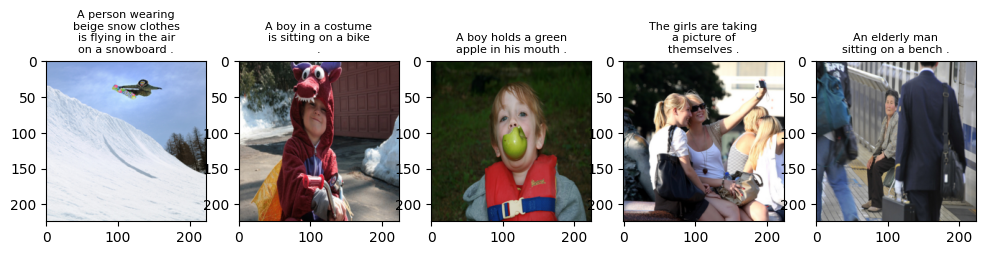

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(train_dataset), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = train_dataset[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

# **ResNet + Text Transformer**

## Pretrained

In [ ]:
import torchvision.models as models
from transformers import BertModel, BertTokenizer

In [ ]:
class Flickr8kDataset1(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.transform = transform
        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                line = line.strip()
                img, caption = line.split(',', 1)
                caption = caption.strip().strip('"')
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        image_files = list(self.image_caption_map.keys())

        np.random.seed(42)
        np.random.shuffle(image_files)

        split_idx = int(len(image_files) * split)
        if mode == "train":
            image_files = image_files[:split_idx]
        elif mode == "val":
            image_files = image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

        # load all images into RAM at init time
        print(f"Caching {len(image_files)} images into RAM...")
        self.samples = []
        for img_name in tqdm(image_files):
            img_path = os.path.join(image_dir, img_name)
            with open(img_path, 'rb') as f:
                img_bytes = f.read()
            caption = self.image_caption_map[img_name]
            self.samples.append((img_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_bytes, caption = self.samples[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, caption

### Pretrained Image Encoder

In [ ]:
resnet18_pretrained = models.ResNet18_Weights.DEFAULT
resnet18_pretrained

ResNet18_Weights.IMAGENET1K_V1

In [ ]:
transform = resnet18_pretrained.transforms()

resnet18_train_dataset = Flickr8kDataset1(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

resnet18_val_dataset = Flickr8kDataset1(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:26<00:00, 248.24it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:06<00:00, 265.01it/s]


In [ ]:
len(resnet18_train_dataset), len(resnet18_val_dataset)

(6472, 1619)

In [ ]:
resnet18_train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
resnet18_train_dataset[0][0].min(), resnet18_train_dataset[0][0].max(), resnet18_train_dataset[0][0].unique().numel()

(tensor(-2.0665), tensor(2.3960), 725)

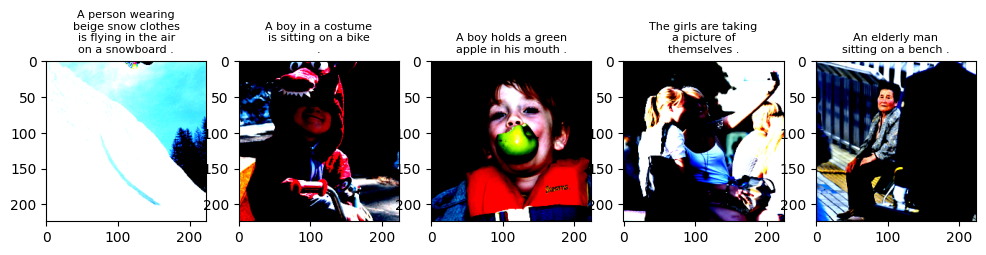

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(resnet18_train_dataset), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = resnet18_train_dataset[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [ ]:
# downloading pretrained model
resnet18_pretrained_model = models.resnet18(weights=resnet18_pretrained)
resnet18_pretrained_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
image_encoder = nn.Sequential(*list(resnet18_pretrained_model.children())[:-1])

In [ ]:
total_params = sum([p.numel() for p in image_encoder.parameters()])

print(f"Total Image Encoder Parameters: {total_params}")
print(f"Total Image Encoder Parameters Size: {(total_params*4)/(1024*1024):.2f} MB")

Total Image Encoder Parameters: 11176512
Total Image Encoder Parameters Size: 42.64 MB


In [ ]:
image_encoder.eval()
with torch.no_grad():
  sample_output = image_encoder(resnet18_train_dataset[0][0].unsqueeze(0))

print(sample_output.shape)

torch.Size([1, 512, 1, 1])


### Pretrained Text Encoder (BERT)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
bert

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### CLIP

In [ ]:
# freeze weights and put both encoders in eval mode
for p in image_encoder.parameters():
  p.requires_grad = False

for p in bert.parameters():
  p.requires_grad = False

image_encoder.eval()
bert.eval()
print("Done!")

Done!


In [ ]:
# collate fn
def collate_method(batch, max_length=None, tokenizer=tokenizer):
  captions = []
  images = []
  for img, caption in batch:
    images.append(img)
    captions.append(caption)

  tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt") # with input_ids and attention_mask
  images_tensor = torch.stack(images, dim=0)

  return images_tensor, tokens

In [ ]:
from functools import partial

collate_fn = partial(collate_method, max_length=None, tokenizer=tokenizer)

train_loader1 = DataLoader(resnet18_train_dataset, batch_size=100, collate_fn=collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader1 = DataLoader(resnet18_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

In [ ]:
class CLIP1(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(512, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    self.temperature = nn.Parameter(torch.tensor(0.07)) # initialized as per CLIP paper

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 512, 1, 1)
    img_embeddings = self.img_proj(img_features.reshape(-1, 512)) # shape (batch, emb_dim)
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)

    text_outputs = self.text_encoder(**tokens)
    hidden = text_outputs.last_hidden_state # (batch, seq_len, 768)
    mask = tokens['attention_mask'].unsqueeze(-1)
    mean_embeddings = (hidden * mask).sum(1) / mask.sum(1) # (batch, 768)
    text_embeddings = self.text_proj(mean_embeddings)
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    return logits

In [ ]:
torch.manual_seed(123)
model1 = CLIP1(image_encoder, bert, emb_dim=256)
model1.to(device)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader1)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step1 = -1
train_losses1, val_losses1 = [], []
train_r_at_1_lst, val_r_at_1_lst = [], []

t1 = time.time()

model1.train()
model1.image_encoder.eval()
model1.text_encoder.eval()
for epoch in range(epochs):
  for batch in train_loader1:
    optimizer1.zero_grad()
    loss, _ = calc_batch_loss(model1, batch, device)
    loss.backward()
    optimizer1.step()
    global_step1 += 1

    if global_step1 % 50 == 0:
      elapsed = time.time() - t1
      steps_done = global_step1 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model1.eval()
      train_loss1, train_r_at_1 = evaluate(train_loader1, model1, device, max_batch=5)
      val_loss1, val_r_at_1 = evaluate(val_loader1, model1, device, max_batch=5)
      model1.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step1:5d}")
      print(f"\t\t\tTrain Loss: {train_loss1:.4f}\t\tTrain R@1: {train_r_at_1*100} %")
      print(f"\t\t\tValidation Loss: {val_loss1:.4f}\t\tValidation R@1: {val_r_at_1*100} %")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses1.append(train_loss1)
      val_losses1.append(val_loss1)
      train_r_at_1_lst.append(train_r_at_1)
      val_r_at_1_lst.append(val_r_at_1)
      model1.train()
      model1.image_encoder.eval()
      model1.text_encoder.eval()

t2 = time.time()

print(f"Total training time: {t2-t1}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6064		Train R@1: 0.6 %
			Validation Loss: 4.6067		Validation R@1: 1.0 %
			ETA: 29.71 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.3009		Train R@1: 12.2 %
			Validation Loss: 4.2899		Validation R@1: 11.600000000000001 %
			ETA: 12.55 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.1481		Train R@1: 17.4 %
			Validation Loss: 4.1456		Validation R@1: 17.4 %
			ETA: 10.51 minutes
Epoch:   2 		 Step:   150
			Train Loss: 4.0848		Train R@1: 18.8 %
			Validation Loss: 4.0786		Validation R@1: 20.0 %
			ETA: 9.23 minutes
Epoch:   3 		 Step:   200
			Train Loss: 4.0391		Train R@1: 23.799999999999997 %
			Validation Loss: 4.0391		Validation R@1: 21.8 %
			ETA: 8.21 minutes
Epoch:   3 		 Step:   250
			Train Loss: 3.9943		Train R@1: 25.0 %
			Validation Loss: 4.0112		Validation R@1: 22.6 %
			ETA: 7.21 minutes
Epoch:   4 		 Step:   300
			Train Loss: 3.9817		Train R@1: 26.400000000000002 %
			Validation Loss: 3.9901		Validation 

In [ ]:
torch.save(model1.state_dict(), "/content/drive/My Drive/clip_resnet_bert.pth")

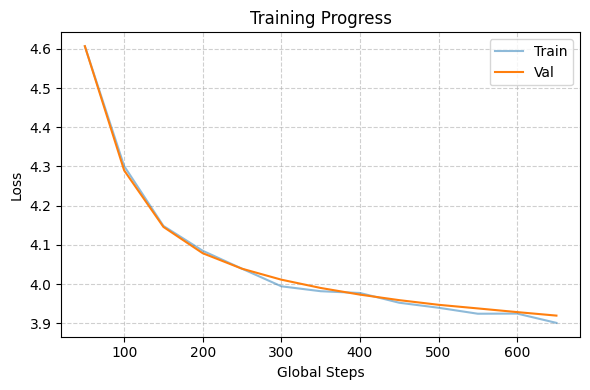

In [ ]:
plot_training_results(train_losses1, val_losses1, 50, title="Training Progress")

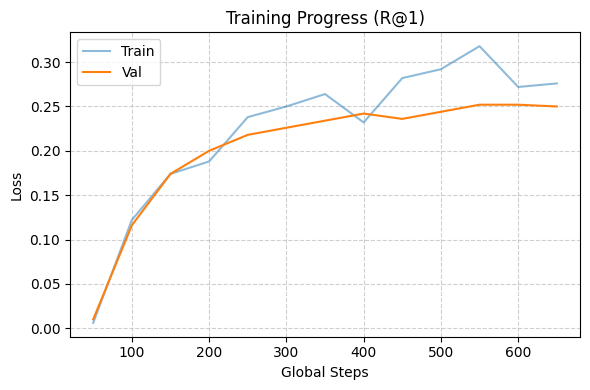

In [ ]:
plot_training_results(train_r_at_1_lst, val_r_at_1_lst, 50, title="Training Progress (R@1)")

In [ ]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP1(image_encoder, bert, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_resnet_bert.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader1, device)
print()
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:15<00:00,  1.10it/s]


{'i2t_r@1': 0.2464484249536751, 't2i_r@1': 0.23162445954292774, 'mean_r@1': 0.23903644224830142}


#### Visualizing Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features.reshape(-1, 512))
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            text_outputs = model.text_encoder(**tokens)
            hidden = text_outputs.last_hidden_state
            mask = tokens['attention_mask'].unsqueeze(-1)

            mean_emb = (hidden * mask).sum(1) / mask.sum(1)
            text_emb = model.text_proj(mean_emb)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2263/3250516455.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


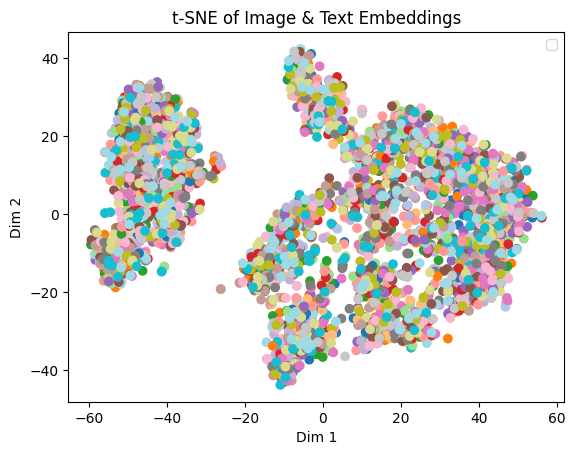

In [ ]:
img_embs, text_embs = get_embeddings(model1, val_loader1, device=device)
plot_tsne(img_embs, text_embs)

# **ViT + Text Transformer**

## Pretrained

In [10]:
import torchvision.models as models
from transformers import BertModel, BertTokenizer

### Pretrained Image Encoder

In [11]:
vitb16_pretrained = models.ViT_B_16_Weights.DEFAULT
vitb16_pretrained

ViT_B_16_Weights.IMAGENET1K_V1

In [8]:
class Flickr8kDataset2(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.transform = transform
        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                line = line.strip()
                img, caption = line.split(',', 1)
                caption = caption.strip().strip('"')
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        image_files = list(self.image_caption_map.keys())

        np.random.seed(42)
        np.random.shuffle(image_files)

        split_idx = int(len(image_files) * split)
        if mode == "train":
            image_files = image_files[:split_idx]
        elif mode == "val":
            image_files = image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

        # load all images into RAM at init time
        print(f"Caching {len(image_files)} images into RAM...")
        self.samples = []
        for img_name in tqdm(image_files):
            img_path = os.path.join(image_dir, img_name)
            with open(img_path, 'rb') as f:
                img_bytes = f.read()
            caption = self.image_caption_map[img_name]
            self.samples.append((img_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_bytes, caption = self.samples[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, caption

In [ ]:
transform = vitb16_pretrained.transforms()

vitb16_train_dataset = Flickr8kDataset2(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

vitb16_val_dataset = Flickr8kDataset2(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:22<00:00, 291.99it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:05<00:00, 271.43it/s]


In [ ]:
len(vitb16_train_dataset), len(vitb16_val_dataset)

(6472, 1619)

In [ ]:
vitb16_train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
vitb16_train_dataset[0][0].min(), vitb16_train_dataset[0][0].max(), vitb16_train_dataset[0][0].unique().numel()

(tensor(-2.0665), tensor(2.3960), 725)

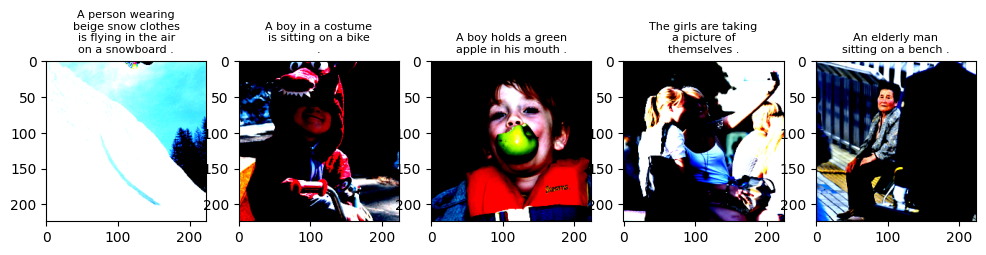

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(vitb16_train_dataset), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = vitb16_train_dataset[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [12]:
# downloading pretrained model
vitb16_pretrained_model = models.vit_b_16(weights=vitb16_pretrained)
vitb16_pretrained_model

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 178MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [13]:
vitb16_pretrained_model.heads = nn.Identity()
image_encoder = vitb16_pretrained_model
image_encoder

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [14]:
total_params = sum([p.numel() for p in image_encoder.parameters()])

print(f"Total Image Encoder Parameters: {total_params}")
print(f"Total Image Encoder Parameters Size: {(total_params*4)/(1024*1024):.2f} MB")

Total Image Encoder Parameters: 85798656
Total Image Encoder Parameters Size: 327.30 MB


In [ ]:
# output shape of vit encoder
image_encoder.eval()
with torch.no_grad():
  sample_output = image_encoder(vitb16_train_dataset[0][0].unsqueeze(0))

print(sample_output.shape)

torch.Size([1, 768])


### Pretrained Text Encoder (BERT)

In [15]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
bert

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### CLIP - Learnable Temperature

In [ ]:
# freeze weights and put both encoders in eval mode
for p in image_encoder.parameters():
  p.requires_grad = False

for p in bert.parameters():
  p.requires_grad = False

image_encoder.eval()
bert.eval()
print("Done!")

Done!


In [23]:
# collate fn
def collate_method(batch, max_length=None, tokenizer=tokenizer):
  captions = []
  images = []
  for img, caption in batch:
    images.append(img)
    captions.append(caption)

  tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt") # with input_ids and attention_mask
  images_tensor = torch.stack(images, dim=0)

  return images_tensor, tokens

In [ ]:
from functools import partial

collate_fn = partial(collate_method, max_length=None, tokenizer=tokenizer)

train_loader2 = DataLoader(vitb16_train_dataset, batch_size=100, collate_fn=collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader2 = DataLoader(vitb16_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

In [17]:
class CLIP2(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(768, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    self.temperature = nn.Parameter(torch.tensor(0.07)) # initialized as per CLIP paper
    # self.temperature = torch.tensor(0.07)

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 768)
    img_embeddings = self.img_proj(img_features) # shape (batch, emb_dim)
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)

    text_outputs = self.text_encoder(**tokens)
    hidden = text_outputs.last_hidden_state # (batch, seq_len, 768)
    mask = tokens['attention_mask'].unsqueeze(-1)
    mean_embeddings = (hidden * mask).sum(1) / mask.sum(1) # (batch, 768)
    text_embeddings = self.text_proj(mean_embeddings)
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    return logits

In [ ]:
torch.manual_seed(123)
model2 = CLIP2(image_encoder, bert, emb_dim=256)
model2.to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader2)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step2 = -1
train_losses2, val_losses2 = [], []
train_r_at_2_lst, val_r_at_2_lst = [], []

t3 = time.time()

model2.train()
model2.image_encoder.eval()
model2.text_encoder.eval()
for epoch in range(epochs):
  for batch in train_loader2:
    optimizer2.zero_grad()
    loss, _ = calc_batch_loss(model2, batch, device)
    loss.backward()
    optimizer2.step()
    global_step2 += 1

    if global_step2 % 50 == 0:
      elapsed = time.time() - t3
      steps_done = global_step2 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model2.eval()
      train_loss2, train_r_at_2 = evaluate(train_loader2, model2, device, max_batch=5)
      val_loss2, val_r_at_2 = evaluate(val_loader2, model2, device, max_batch=5)
      model2.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step2:5d}")
      print(f"\t\t\tTrain Loss: {train_loss2:.4f}\t\tTrain R@1: {train_r_at_2*100} %")
      print(f"\t\t\tValidation Loss: {val_loss2:.4f}\t\tValidation R@1: {val_r_at_2*100} %")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses2.append(train_loss2)
      val_losses2.append(val_loss2)
      train_r_at_2_lst.append(train_r_at_2)
      val_r_at_2_lst.append(val_r_at_2)
      model2.train()
      model2.image_encoder.eval()
      model2.text_encoder.eval()

t4 = time.time()

print(f"Total training time: {t4-t3}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6037		Train R@1: 1.2 %
			Validation Loss: 4.6032		Validation R@1: 0.6 %
			ETA: 19.79 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.3453		Train R@1: 15.4 %
			Validation Loss: 4.3640		Validation R@1: 11.4 %
			ETA: 24.24 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.1847		Train R@1: 23.599999999999998 %
			Validation Loss: 4.2077		Validation R@1: 18.8 %
			ETA: 21.78 minutes
Epoch:   2 		 Step:   150
			Train Loss: 4.0821		Train R@1: 28.999999999999996 %
			Validation Loss: 4.1222		Validation R@1: 21.0 %
			ETA: 19.36 minutes
Epoch:   3 		 Step:   200
			Train Loss: 4.0569		Train R@1: 27.800000000000004 %
			Validation Loss: 4.0675		Validation R@1: 22.2 %
			ETA: 17.25 minutes
Epoch:   3 		 Step:   250
			Train Loss: 4.0191		Train R@1: 28.799999999999997 %
			Validation Loss: 4.0298		Validation R@1: 24.2 %
			ETA: 15.15 minutes
Epoch:   4 		 Step:   300
			Train Loss: 3.9875		Train R@1: 28.4 %
			Validation Loss: 4.

In [ ]:
torch.save(model2.state_dict(), "/content/drive/My Drive/clip_vit_bert.pth")

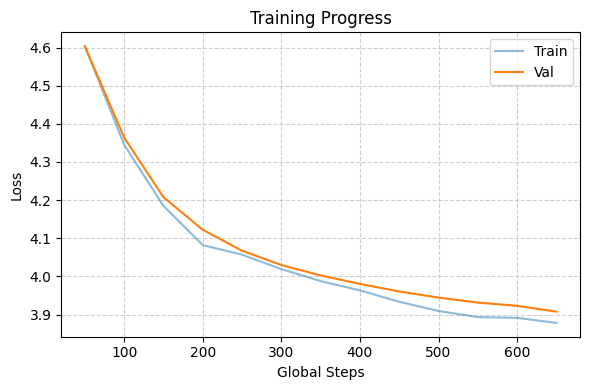

In [ ]:
plot_training_results(train_losses2, val_losses2, 50, title="Training Progress")

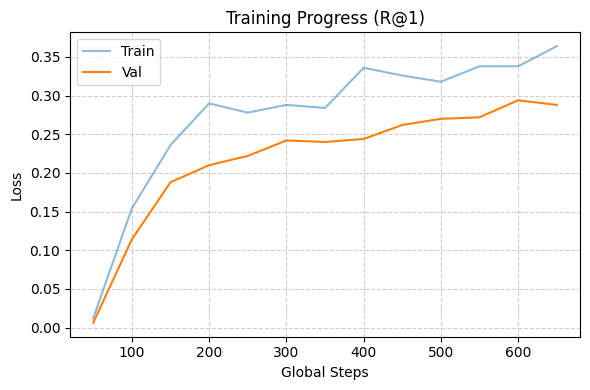

In [ ]:
plot_training_results(train_r_at_2_lst, val_r_at_2_lst, 50, title="Training Progress (R@1)")

In [25]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP2(image_encoder, bert, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader2, device)
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:32<00:00,  1.91s/it]

{'i2t_r@1': 0.27486102532427426, 't2i_r@1': 0.2526250772081532, 'mean_r@1': 0.2637430512662137}


#### Visualizing Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features)
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            text_outputs = model.text_encoder(**tokens)
            hidden = text_outputs.last_hidden_state
            mask = tokens['attention_mask'].unsqueeze(-1)

            mean_emb = (hidden * mask).sum(1) / mask.sum(1)
            text_emb = model.text_proj(mean_emb)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2157/807819391.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


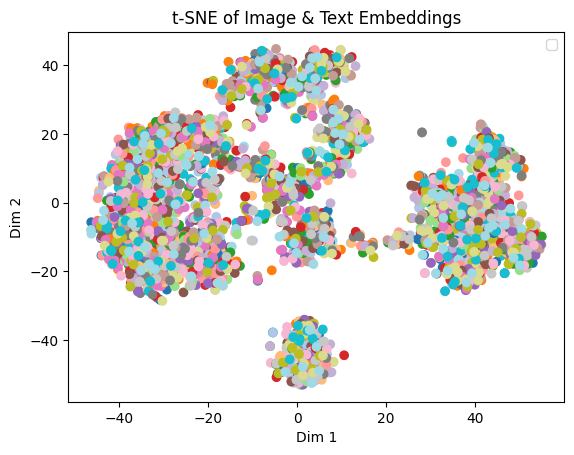

In [ ]:
img_embs, text_embs = get_embeddings(model2, val_loader2, device=device)
plot_tsne(img_embs, text_embs)

### CLIP - Temperature = 0.07 (fixed)

In [ ]:
# freeze weights and put both encoders in eval mode
for p in image_encoder.parameters():
  p.requires_grad = False

for p in bert.parameters():
  p.requires_grad = False

image_encoder.eval()
bert.eval()
print("Done!")

Done!


In [ ]:
# collate fn
def collate_method(batch, max_length=None, tokenizer=tokenizer):
  captions = []
  images = []
  for img, caption in batch:
    images.append(img)
    captions.append(caption)

  tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt") # with input_ids and attention_mask
  images_tensor = torch.stack(images, dim=0)

  return images_tensor, tokens

In [ ]:
from functools import partial

collate_fn = partial(collate_method, max_length=None, tokenizer=tokenizer)

train_loader4 = DataLoader(vitb16_train_dataset, batch_size=100, collate_fn=collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader4 = DataLoader(vitb16_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

In [26]:
class CLIP4(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(768, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    self.temperature = torch.tensor(0.07)

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 768)
    img_embeddings = self.img_proj(img_features) # shape (batch, emb_dim)
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)

    text_outputs = self.text_encoder(**tokens)
    hidden = text_outputs.last_hidden_state # (batch, seq_len, 768)
    mask = tokens['attention_mask'].unsqueeze(-1)
    mean_embeddings = (hidden * mask).sum(1) / mask.sum(1) # (batch, 768)
    text_embeddings = self.text_proj(mean_embeddings)
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    return logits

In [ ]:
torch.manual_seed(123)
model4 = CLIP4(image_encoder, bert, emb_dim=256)
model4.to(device)

optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader2)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step4 = -1
train_losses4, val_losses4 = [], []
train_r_at_4_lst, val_r_at_4_lst = [], []

t7 = time.time()

model4.train()
model4.image_encoder.eval()
model4.text_encoder.eval()
for epoch in range(epochs):
  for batch in train_loader4:
    optimizer4.zero_grad()
    loss, _ = calc_batch_loss(model4, batch, device)
    loss.backward()
    optimizer4.step()
    global_step4 += 1

    if global_step4 % 50 == 0:
      elapsed = time.time() - t7
      steps_done = global_step4 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model4.eval()
      train_loss4, train_r_at_4 = evaluate(train_loader4, model4, device, max_batch=5)
      val_loss4, val_r_at_4 = evaluate(val_loader4, model4, device, max_batch=5)
      model4.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step4:5d}")
      print(f"\t\t\tTrain Loss: {train_loss4:.4f}\t\tTrain R@1: {train_r_at_4*100} %")
      print(f"\t\t\tValidation Loss: {val_loss4:.4f}\t\tValidation R@1: {val_r_at_4*100} %")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses4.append(train_loss4)
      val_losses4.append(val_loss4)
      train_r_at_4_lst.append(train_r_at_4)
      val_r_at_4_lst.append(val_r_at_4)
      model4.train()
      model4.image_encoder.eval()
      model4.text_encoder.eval()

t8 = time.time()

print(f"Total training time: {t8-t7}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6037		Train R@1: 1.2 %
			Validation Loss: 4.6032		Validation R@1: 0.6 %
			ETA: 18.04 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.3467		Train R@1: 15.4 %
			Validation Loss: 4.3653		Validation R@1: 11.4 %
			ETA: 21.61 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.1898		Train R@1: 23.799999999999997 %
			Validation Loss: 4.2124		Validation R@1: 18.8 %
			ETA: 19.83 minutes
Epoch:   2 		 Step:   150
			Train Loss: 4.0916		Train R@1: 28.999999999999996 %
			Validation Loss: 4.1308		Validation R@1: 20.599999999999998 %
			ETA: 18.02 minutes
Epoch:   3 		 Step:   200
			Train Loss: 4.0701		Train R@1: 28.199999999999996 %
			Validation Loss: 4.0802		Validation R@1: 22.2 %
			ETA: 16.18 minutes
Epoch:   3 		 Step:   250
			Train Loss: 4.0365		Train R@1: 28.4 %
			Validation Loss: 4.0465		Validation R@1: 23.799999999999997 %
			ETA: 14.34 minutes
Epoch:   4 		 Step:   300
			Train Loss: 4.0090		Train R@1: 28.4 %
			Valid

In [ ]:
torch.save(model4.state_dict(), "/content/drive/My Drive/clip_vit_bert_t_0_07.pth")

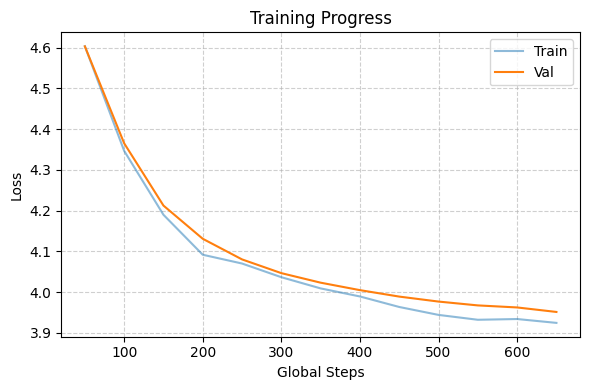

In [ ]:
plot_training_results(train_losses4, val_losses4, 50, title="Training Progress")

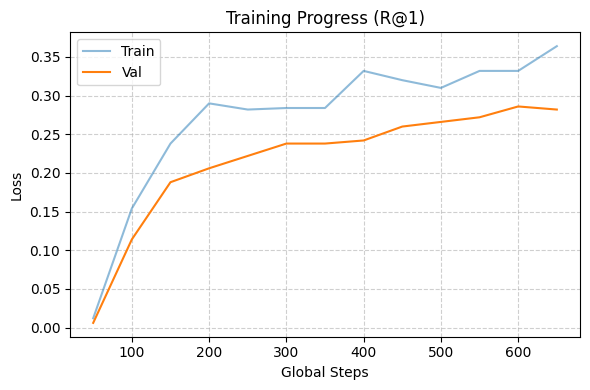

In [ ]:
plot_training_results(train_r_at_4_lst, val_r_at_4_lst, 50, title="Training Progress (R@1)")

In [ ]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP4(image_encoder, bert, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_07.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader4, device)
print()
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:29<00:00,  1.76s/it]


{'i2t_r@1': 0.26930203829524396, 't2i_r@1': 0.24953675108091414, 'mean_r@1': 0.25941939468807906}


#### Visualizing Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features)
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            text_outputs = model.text_encoder(**tokens)
            hidden = text_outputs.last_hidden_state
            mask = tokens['attention_mask'].unsqueeze(-1)

            mean_emb = (hidden * mask).sum(1) / mask.sum(1)
            text_emb = model.text_proj(mean_emb)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2157/807819391.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


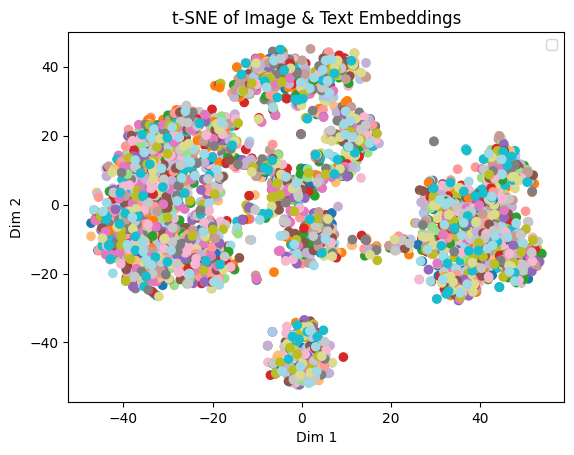

In [ ]:
img_embs, text_embs = get_embeddings(model4, val_loader4, device=device)
plot_tsne(img_embs, text_embs)

### CLIP - Temperature = 0.1 (fixed)

In [ ]:
# freeze weights and put both encoders in eval mode
for p in image_encoder.parameters():
  p.requires_grad = False

for p in bert.parameters():
  p.requires_grad = False

image_encoder.eval()
bert.eval()
print("Done!")

Done!


In [ ]:
# collate fn
def collate_method(batch, max_length=None, tokenizer=tokenizer):
  captions = []
  images = []
  for img, caption in batch:
    images.append(img)
    captions.append(caption)

  tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt") # with input_ids and attention_mask
  images_tensor = torch.stack(images, dim=0)

  return images_tensor, tokens

In [ ]:
from functools import partial

collate_fn = partial(collate_method, max_length=None, tokenizer=tokenizer)

train_loader5 = DataLoader(vitb16_train_dataset, batch_size=100, collate_fn=collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader5 = DataLoader(vitb16_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

In [27]:
class CLIP5(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(768, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    self.temperature = torch.tensor(0.1)

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 768)
    img_embeddings = self.img_proj(img_features) # shape (batch, emb_dim)
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)

    text_outputs = self.text_encoder(**tokens)
    hidden = text_outputs.last_hidden_state # (batch, seq_len, 768)
    mask = tokens['attention_mask'].unsqueeze(-1)
    mean_embeddings = (hidden * mask).sum(1) / mask.sum(1) # (batch, 768)
    text_embeddings = self.text_proj(mean_embeddings)
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    return logits

In [ ]:
torch.manual_seed(123)
model5 = CLIP5(image_encoder, bert, emb_dim=256)
model5.to(device)

optimizer5 = torch.optim.Adam(model5.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader5)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step5 = -1
train_losses5, val_losses5 = [], []
train_r_at_5_lst, val_r_at_5_lst = [], []

t9 = time.time()

model5.train()
model5.image_encoder.eval()
model5.text_encoder.eval()
for epoch in range(epochs):
  for batch in train_loader5:
    optimizer5.zero_grad()
    loss, _ = calc_batch_loss(model5, batch, device)
    loss.backward()
    optimizer5.step()
    global_step5 += 1

    if global_step5 % 50 == 0:
      elapsed = time.time() - t9
      steps_done = global_step5 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model5.eval()
      train_loss5, train_r_at_5 = evaluate(train_loader5, model5, device, max_batch=5)
      val_loss5, val_r_at_5 = evaluate(val_loader5, model5, device, max_batch=5)
      model5.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step5:5d}")
      print(f"\t\t\tTrain Loss: {train_loss5:.4f}\t\tTrain R@1: {train_r_at_5*100} %")
      print(f"\t\t\tValidation Loss: {val_loss5:.4f}\t\tValidation R@1: {val_r_at_5*100} %")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses5.append(train_loss5)
      val_losses5.append(val_loss5)
      train_r_at_5_lst.append(train_r_at_5)
      val_r_at_5_lst.append(val_r_at_5)
      model5.train()
      model5.image_encoder.eval()
      model5.text_encoder.eval()

t10 = time.time()

print(f"Total training time: {t10-t9}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6037		Train R@1: 1.2 %
			Validation Loss: 4.6032		Validation R@1: 0.6 %
			ETA: 48.33 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.3397		Train R@1: 15.4 %
			Validation Loss: 4.3588		Validation R@1: 11.4 %
			ETA: 22.49 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.1790		Train R@1: 23.799999999999997 %
			Validation Loss: 4.2023		Validation R@1: 18.8 %
			ETA: 20.36 minutes
Epoch:   2 		 Step:   150
			Train Loss: 4.0784		Train R@1: 28.799999999999997 %
			Validation Loss: 4.1189		Validation R@1: 20.8 %
			ETA: 18.67 minutes
Epoch:   3 		 Step:   200
			Train Loss: 4.0564		Train R@1: 27.800000000000004 %
			Validation Loss: 4.0671		Validation R@1: 22.2 %
			ETA: 16.89 minutes
Epoch:   3 		 Step:   250
			Train Loss: 4.0220		Train R@1: 28.799999999999997 %
			Validation Loss: 4.0326		Validation R@1: 24.2 %
			ETA: 14.99 minutes
Epoch:   4 		 Step:   300
			Train Loss: 3.9939		Train R@1: 28.599999999999998 %
			Valid

In [ ]:
torch.save(model5.state_dict(), "/content/drive/My Drive/clip_vit_bert_t_0_1.pth")

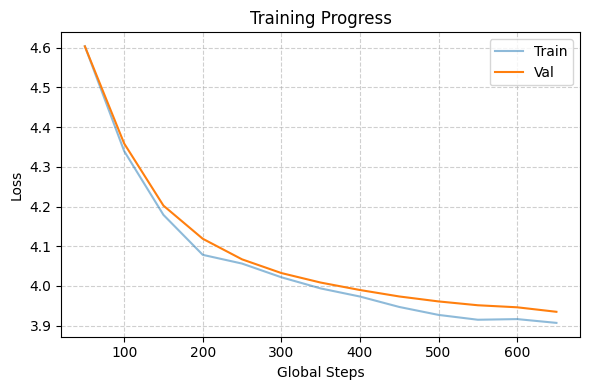

In [ ]:
plot_training_results(train_losses5, val_losses5, 50, title="Training Progress")

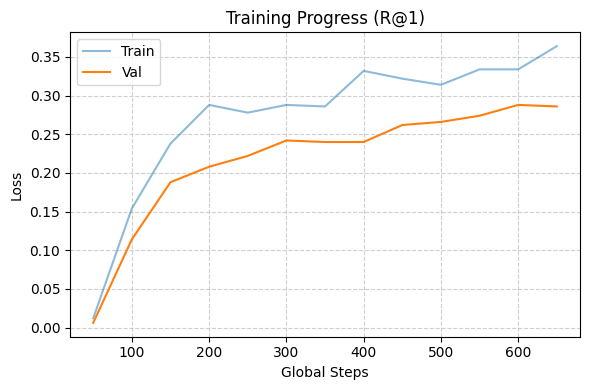

In [ ]:
plot_training_results(train_r_at_5_lst, val_r_at_5_lst, 50, title="Training Progress (R@1)")

In [ ]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP5(image_encoder, bert, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_1.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader5, device)
print()
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:31<00:00,  1.85s/it]


{'i2t_r@1': 0.2699197035206918, 't2i_r@1': 0.25077208153180974, 'mean_r@1': 0.26034589252625073}


#### Visualizing Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features)
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            text_outputs = model.text_encoder(**tokens)
            hidden = text_outputs.last_hidden_state
            mask = tokens['attention_mask'].unsqueeze(-1)

            mean_emb = (hidden * mask).sum(1) / mask.sum(1)
            text_emb = model.text_proj(mean_emb)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2257/807819391.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


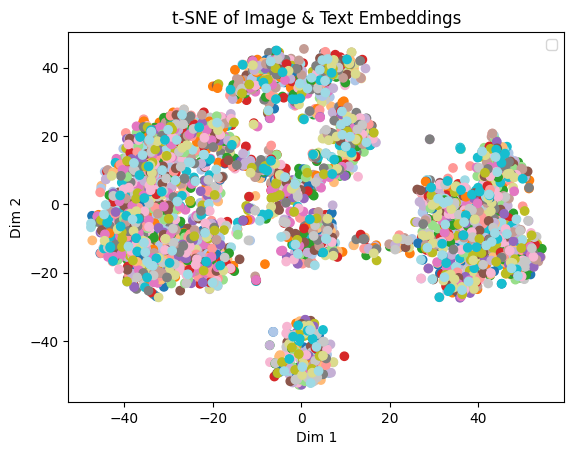

In [ ]:
img_embs, text_embs = get_embeddings(model5, val_loader5, device=device)
plot_tsne(img_embs, text_embs)

### CLIP - Temperature = 0.5 (fixed)

In [ ]:
# freeze weights and put both encoders in eval mode
for p in image_encoder.parameters():
  p.requires_grad = False

for p in bert.parameters():
  p.requires_grad = False

image_encoder.eval()
bert.eval()
print("Done!")

Done!


In [ ]:
# collate fn
def collate_method(batch, max_length=None, tokenizer=tokenizer):
  captions = []
  images = []
  for img, caption in batch:
    images.append(img)
    captions.append(caption)

  tokens = tokenizer(captions, padding=True, truncation=True, return_tensors="pt") # with input_ids and attention_mask
  images_tensor = torch.stack(images, dim=0)

  return images_tensor, tokens

In [ ]:
from functools import partial

collate_fn = partial(collate_method, max_length=None, tokenizer=tokenizer)

train_loader6 = DataLoader(vitb16_train_dataset, batch_size=100, collate_fn=collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader6 = DataLoader(vitb16_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

In [28]:
class CLIP6(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(768, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    self.temperature = torch.tensor(0.5)

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 768)
    img_embeddings = self.img_proj(img_features) # shape (batch, emb_dim)
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)

    text_outputs = self.text_encoder(**tokens)
    hidden = text_outputs.last_hidden_state # (batch, seq_len, 768)
    mask = tokens['attention_mask'].unsqueeze(-1)
    mean_embeddings = (hidden * mask).sum(1) / mask.sum(1) # (batch, 768)
    text_embeddings = self.text_proj(mean_embeddings)
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    return logits

In [ ]:
torch.manual_seed(123)
model6 = CLIP6(image_encoder, bert, emb_dim=256)
model6.to(device)

optimizer6 = torch.optim.Adam(model6.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader6)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step6 = -1
train_losses6, val_losses6 = [], []
train_r_at_6_lst, val_r_at_6_lst = [], []

t11 = time.time()

model6.train()
model6.image_encoder.eval()
model6.text_encoder.eval()
for epoch in range(epochs):
  for batch in train_loader6:
    optimizer6.zero_grad()
    loss, _ = calc_batch_loss(model6, batch, device)
    loss.backward()
    optimizer6.step()
    global_step6 += 1

    if global_step6 % 50 == 0:
      elapsed = time.time() - t11
      steps_done = global_step6 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model6.eval()
      train_loss6, train_r_at_6 = evaluate(train_loader6, model6, device, max_batch=5)
      val_loss6, val_r_at_6 = evaluate(val_loader6, model6, device, max_batch=5)
      model6.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step6:5d}")
      print(f"\t\t\tTrain Loss: {train_loss6:.4f}\t\tTrain R@1: {train_r_at_6*100} %")
      print(f"\t\t\tValidation Loss: {val_loss6:.4f}\t\tValidation R@1: {val_r_at_6*100} %")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses6.append(train_loss6)
      val_losses6.append(val_loss6)
      train_r_at_6_lst.append(train_r_at_6)
      val_r_at_6_lst.append(val_r_at_6)
      model6.train()
      model6.image_encoder.eval()
      model6.text_encoder.eval()

t12 = time.time()

print(f"Total training time: {t12-t11}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6043		Train R@1: 1.2 %
			Validation Loss: 4.6034		Validation R@1: 0.6 %
			ETA: 21.22 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.2293		Train R@1: 15.8 %
			Validation Loss: 4.2563		Validation R@1: 11.4 %
			ETA: 24.53 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.0124		Train R@1: 24.6 %
			Validation Loss: 4.0478		Validation R@1: 19.400000000000002 %
			ETA: 22.38 minutes
Epoch:   2 		 Step:   150
			Train Loss: 3.8754		Train R@1: 30.4 %
			Validation Loss: 3.9372		Validation R@1: 21.4 %
			ETA: 20.19 minutes
Epoch:   3 		 Step:   200
			Train Loss: 3.8467		Train R@1: 29.799999999999997 %
			Validation Loss: 3.8679		Validation R@1: 24.6 %
			ETA: 18.12 minutes
Epoch:   3 		 Step:   250
			Train Loss: 3.7989		Train R@1: 30.8 %
			Validation Loss: 3.8220		Validation R@1: 25.2 %
			ETA: 16.05 minutes
Epoch:   4 		 Step:   300
			Train Loss: 3.7623		Train R@1: 31.4 %
			Validation Loss: 3.7903		Validation R@1: 25.8 %

In [ ]:
torch.save(model6.state_dict(), "/content/drive/My Drive/clip_vit_bert_t_0_5.pth")

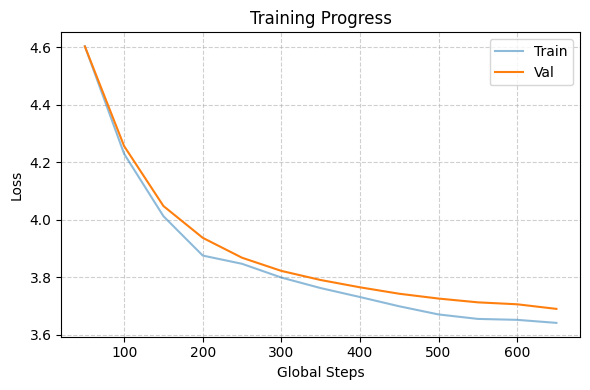

In [ ]:
plot_training_results(train_losses6, val_losses6, 50, title="Training Progress")

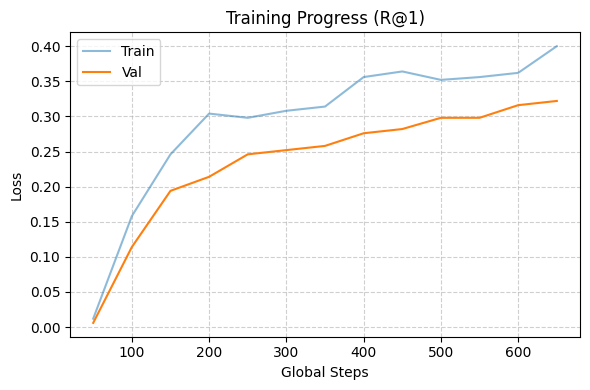

In [ ]:
plot_training_results(train_r_at_6_lst, val_r_at_6_lst, 50, title="Training Progress (R@1)")

In [ ]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP6(image_encoder, bert, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_5.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader6, device)
print()
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:37<00:00,  2.20s/it]


{'i2t_r@1': 0.30018529956763434, 't2i_r@1': 0.28474366893143915, 'mean_r@1': 0.29246448424953675}


#### Visualizing Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features)
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            text_outputs = model.text_encoder(**tokens)
            hidden = text_outputs.last_hidden_state
            mask = tokens['attention_mask'].unsqueeze(-1)

            mean_emb = (hidden * mask).sum(1) / mask.sum(1)
            text_emb = model.text_proj(mean_emb)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2257/807819391.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


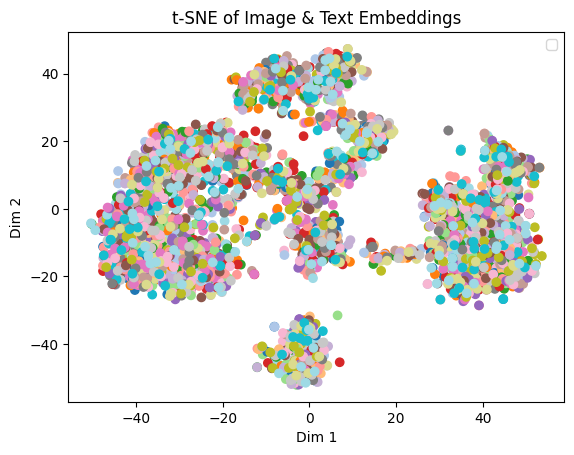

In [ ]:
img_embs, text_embs = get_embeddings(model6, val_loader6, device=device)
plot_tsne(img_embs, text_embs)

### Temperature Comparison

In [29]:
def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def evaluate_and_plot(models: dict, val_loader, device="cuda"):
    results = {}
    for name, model in models.items():
        print(f"\nEvaluating: {name}")
        results[name] = compute_r_at_1(model, val_loader, device)

    model_names = list(results.keys())
    metrics     = ["i2t_r@1",      "t2i_r@1",      "mean_r@1"]
    xlabels     = ["Image → Text", "Text → Image", "Mean R@1"]
    colors      = ["#378ADD", "#1D9E75", "#D85A30", "#9370DB"]

    n_models = len(model_names)
    width    = 0.8 / n_models
    x        = np.arange(len(metrics))

    fig, ax = plt.subplots(figsize=(7, 5))

    for i, name in enumerate(model_names):
        scores = [results[name][m] for m in metrics]
        offset = (i - n_models / 2 + 0.5) * width
        bars   = ax.bar(x + offset, scores, width, label=name, color=colors[i % len(colors)])

        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.004,
                f"{h:.3f}",
                ha="center", va="bottom", fontsize=7
            )

    all_scores = [results[n][m] for n in model_names for m in metrics]

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel("R@1 Score")
    ax.set_ylim(0, min(1.0, max(all_scores) + 0.12))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.legend(title="model", loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    return results


Evaluating: learnable


Evaluating R@1: 100%|██████████| 17/17 [00:36<00:00,  2.14s/it]



Evaluating: 0.07


Evaluating R@1: 100%|██████████| 17/17 [00:33<00:00,  1.97s/it]



Evaluating: 0.1


Evaluating R@1: 100%|██████████| 17/17 [00:33<00:00,  1.97s/it]



Evaluating: 0.5


Evaluating R@1: 100%|██████████| 17/17 [00:34<00:00,  2.00s/it]


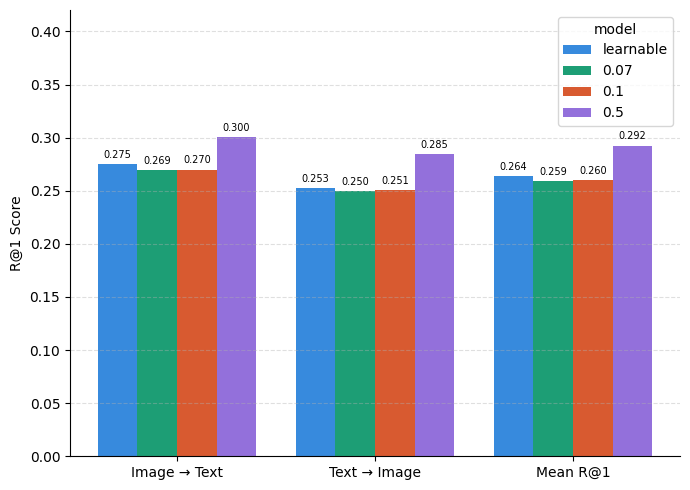

In [32]:
model_l = CLIP2(image_encoder, bert, emb_dim=256)
model_l.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert.pth", weights_only=False))
model_l.to(device)

model_0_07 = CLIP4(image_encoder, bert, emb_dim=256)
model_0_07.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_07.pth", weights_only=False))
model_0_07.to(device)

model_0_1 = CLIP5(image_encoder, bert, emb_dim=256)
model_0_1.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_1.pth", weights_only=False))
model_0_1.to(device)

model_0_5 = CLIP6(image_encoder, bert, emb_dim=256)
model_0_5.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_bert_t_0_5.pth", weights_only=False))
model_0_5.to(device)

models = {"learnable": model_l, "0.07": model_0_07, "0.1": model_0_1, "0.5": model_0_5}
vitb16_val_dataset = Flickr8kDataset2(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)
val_loader = DataLoader(vitb16_val_dataset, batch_size=100, collate_fn=collate_fn, shuffle=False, drop_last=False, num_workers=0)

results = evaluate_and_plot(models, val_loader)

## From Scratch

In [8]:
class Flickr8kDataset3(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.transform = transform
        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                line = line.strip()
                img, caption = line.split(',', 1)
                caption = caption.strip().strip('"')
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        image_files = list(self.image_caption_map.keys())

        np.random.seed(42)
        np.random.shuffle(image_files)

        split_idx = int(len(image_files) * split)
        if mode == "train":
            image_files = image_files[:split_idx]
        elif mode == "val":
            image_files = image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

        # load all images into RAM at init time
        print(f"Caching {len(image_files)} images into RAM...")
        self.samples = []
        for img_name in tqdm(image_files):
            img_path = os.path.join(image_dir, img_name)
            with open(img_path, 'rb') as f:
                img_bytes = f.read()
            caption = self.image_caption_map[img_name]
            self.samples.append((img_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_bytes, caption = self.samples[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, caption

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
])

vit_train_dataset = Flickr8kDataset3(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

vit_val_dataset = Flickr8kDataset3(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:14<00:00, 435.90it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:03<00:00, 457.59it/s]


In [10]:
len(vit_train_dataset), len(vit_val_dataset)

(6472, 1619)

In [11]:
vit_train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [12]:
vit_train_dataset[0][0].min(), vit_train_dataset[0][0].max(), vit_train_dataset[0][0].unique().numel()

(tensor(-2.0837), tensor(2.3437), 724)

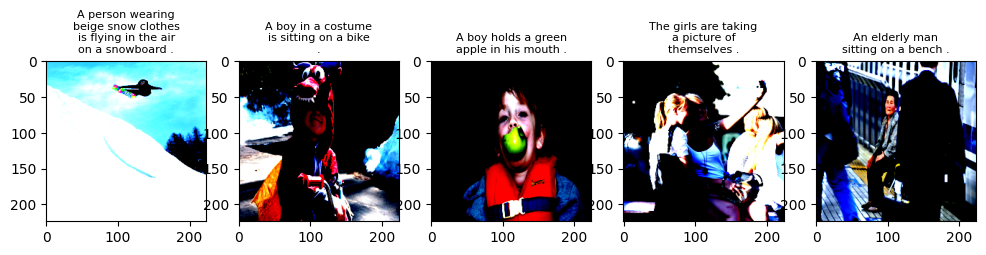

In [13]:
np.random.seed(123)

random_indices = np.random.choice(len(vit_train_dataset), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = vit_train_dataset[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [14]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
    }
)

In [15]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startoftext|>'}

In [16]:
def collate_fn(batch, tokenizer, sot_id=50257, eot_id=50256, pad_id=50258, allowed_max_length=76):
  images = []
  tokenized_captions = []
  input_tokens = []
  token_masks = []
  for img, cap in batch:
    tokenized_text = tokenizer.encode(cap)
    tokenized_captions.append(tokenized_text)
    images.append(img)

  batch_max_length = max([len(x)+2 for x in tokenized_captions])

  for tokens in tokenized_captions:
    new_tokens = [sot_id] + tokens + [eot_id]
    mask = [1] * len(new_tokens)

    padded_tokens = new_tokens + [pad_id] * (batch_max_length - len(new_tokens))
    mask = mask + [0] * (batch_max_length - len(mask))

    if allowed_max_length is not None:
      padded_tokens = padded_tokens[:allowed_max_length]
      mask = mask[:allowed_max_length]

    input_tokens.append(torch.tensor(padded_tokens))
    token_masks.append(torch.tensor(mask))

  text_inputs = {"tokens": torch.stack(input_tokens), "masks": torch.stack(token_masks)}
  image_inputs = torch.stack(images, dim=0)

  return image_inputs, text_inputs

In [17]:
from functools import partial

custom_collate_fn = partial(collate_fn, tokenizer=tokenizer)

train_loader3 = DataLoader(vit_train_dataset, batch_size=100, collate_fn=custom_collate_fn, shuffle=True, drop_last=True, num_workers=0)
val_loader3 = DataLoader(vit_val_dataset, batch_size=100, collate_fn=custom_collate_fn, shuffle=False, drop_last=False, num_workers=0)

### ViT

In [18]:
ViT_CONFIG = {
    'emb_size':768,
    'patch_size': (16, 16),
    'patch_num': 14 * 14,
    "hidden_dim": 512,
    'num_heads':12,
    'num_layers':12,
    'drop_rate':0.1,
    'qkv_bias':False,
}

In [19]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [20]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [21]:
class FFN(nn.Module):
  def __init__(self, emb_size, hidden_dim):
    super().__init__()
    self.ffn = nn.Sequential(
        nn.Linear(emb_size, hidden_dim),
        GeLU(),
        nn.Linear(hidden_dim, emb_size)
    )

  def forward(self, x):
    return self.ffn(x)

In [22]:
class MultiHeadAttention1(nn.Module): # bidirectional
  def __init__(self, dim_in, dim_out, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3) # bidirectional attention

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [23]:
class EncoderBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttention1(cfg['emb_size'], cfg['emb_size'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FFN(cfg['emb_size'], cfg['hidden_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [24]:
class ViTEncoder(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.conv_proj = nn.Conv2d(3, 768, kernel_size=cfg["patch_size"], stride=cfg["patch_size"])
    self.encoder_blocks = nn.Sequential(
        *[EncoderBlock(cfg) for _ in range(cfg["num_layers"])]
    )
    self.final_norm = LayerNorm(cfg["emb_size"])
    self.positional_embeddings = nn.Embedding(cfg["patch_num"]+1, cfg["emb_size"])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.cls_embedding = nn.Parameter(torch.zeros(1, 1, cfg["emb_size"]))
    nn.init.trunc_normal_(self.cls_embedding, std=0.02)

  def forward(self, imgs):
    patch_embeddings = self.conv_proj(imgs).flatten(2).permute(0,2,1) # (b, 3, 224, 224) -> (b, 768, 14, 14) -> (b, 768, 14*14) -> (b, 14*14, 768)
    batch_size, patches, emb_dim = patch_embeddings.shape
    cls_tokens = self.cls_embedding.expand(batch_size, -1, -1)   # (b, 1, 768)
    embeddings = torch.cat((cls_tokens, patch_embeddings), dim=1)  # (b, 14*14 + 1, 768)
    pos_embeddings = self.positional_embeddings(torch.arange(embeddings.shape[1], device=imgs.device))

    x = embeddings + pos_embeddings
    x = self.dropout_layer(x)
    x = self.final_norm(self.encoder_blocks(x))
    img_features = x[:, 0, :] # embedding of CLS tokens from last encoder block

    return img_features

### Text encoder (Decoder-Transformer)

In [25]:
GPT_CONFIG = {                       # as per CLIP paper
    'emb_size':768,
    'context_length':76,
    'hidden_dim': 512,
    'vocab_size': tokenizer.n_vocab,
    'num_heads':8,
    'num_layers':12,
    'drop_rate':0.1,
    'qkv_bias':False,
}

In [26]:
class MultiHeadAttention2(nn.Module): # causal
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [27]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttention2(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FFN(cfg['emb_size'], cfg['hidden_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [28]:
class TextTransformer(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    logits = self.final_norm(x)

    return logits

### CLIP

In [29]:
class CLIP3(nn.Module):
  def __init__(self, image_encoder, text_encoder, emb_dim): # both encoders should be in eval mode with frozen wieghts
    super().__init__()
    self.image_encoder = image_encoder
    self.text_encoder = text_encoder
    self.img_proj = nn.Linear(768, emb_dim)
    self.text_proj = nn.Linear(768, emb_dim)
    # self.temperature = nn.Parameter(torch.tensor(0.07)) # initialized as per CLIP paper
    self.temperature = torch.tensor(0.5)

  def forward(self, imgs, tokens):
    img_features = self.image_encoder(imgs) # (batch, 768)
    img_embeddings = self.img_proj(img_features) # shape (batch, emb_dim)
    # print(f"Image embeddings L2 norm mean (before normalizing): {torch.linalg.norm(img_embeddings, dim=-1).mean()}")
    img_embeddings = img_embeddings / torch.linalg.norm(img_embeddings, dim=-1).unsqueeze(-1) # L2-normalized vectors; shape of torch.llinalg.norm (batch,); final img_embeddings tensor shape (batch, emb_dim)
    # img_embeddings = nn.functional.normalize(img_embeddings, dim=-1)

    logits = self.text_encoder(tokens["tokens"])
    last_token_idx = tokens["masks"].sum(1) - 1
    last_token_idx = last_token_idx.unsqueeze(1).unsqueeze(2)          # (batch, 1, 1)
    last_token_idx = last_token_idx.expand(-1, 1, logits.size(-1))     # (batch, 1, 768)
    text_features = torch.gather(logits, dim=1, index=last_token_idx).squeeze(1)  # (batch, 768); last tokens or eot's embeddings
    text_embeddings = self.text_proj(text_features) # (batch, emb_dim)
    # print(f"Text embeddings L2 norm mean (before normalizing): {torch.linalg.norm(text_embeddings, dim=-1).mean()}")
    text_embeddings = text_embeddings / torch.linalg.norm(text_embeddings, dim=-1).unsqueeze(-1)
    # text_embeddings = nn.functional.normalize(text_embeddings, dim=-1)

    scaling_factor = torch.clip(torch.exp(self.temperature), max=100) # clipping the scaling temperature for stable training and reduction gradient spikes
    logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)

    # scaling_factor = torch.exp(self.temperature)
    # logits = (img_embeddings @ text_embeddings.T) * scaling_factor # (batch, batch)
    # print(logits)

    return logits

In [30]:
# initialize both encoders
vit = ViTEncoder(ViT_CONFIG)
gpt = TextTransformer(GPT_CONFIG)

In [31]:
total_params = sum([p.numel() for p in vit.parameters()])

print(f"Total Image Encoder Parameters: {total_params}")
print(f"Total Image Encoder Parameters Size: {(total_params*4)/(1024*1024):.2f} MB")

total_params = sum([p.numel() for p in gpt.parameters()])

print(f"Total Text Encoder Parameters: {total_params}")
print(f"Total Text Encoder Parameters Size: {(total_params*4)/(1024*1024):.2f} MB")

Total Image Encoder Parameters: 38554368
Total Image Encoder Parameters Size: 147.07 MB
Total Text Encoder Parameters: 76468992
Total Text Encoder Parameters Size: 291.71 MB


In [32]:
torch.manual_seed(123)
model3 = CLIP3(vit, gpt, emb_dim=256)
model3.to(device)

optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)
epochs = 10
total_steps = epochs * len(train_loader3)
print(f"Total Steps: {total_steps}")

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step3 = -1
train_losses3, val_losses3 = [], []
train_r_at_3_lst, val_r_at_3_lst = [], []

t5 = time.time()

model3.train()
for epoch in range(epochs):
  for batch in train_loader3:
    optimizer3.zero_grad()
    loss, _ = calc_batch_loss(model3, batch, device)
    loss.backward()
    total_norm = 0
    for name, p in model3.named_parameters():
      if p.requires_grad:
        param_norm = torch.norm(p.grad)
        # print(f"{name}: {param_norm:.6f}")
        total_norm += param_norm ** 2
    total_norm = total_norm ** 0.5
    optimizer3.step()
    global_step3 += 1

    if global_step3 % 50 == 0:
      elapsed = time.time() - t5
      steps_done = global_step3 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
      steps_left = total_steps - steps_done
      time_per_step = elapsed / steps_done
      eta_seconds = steps_left * time_per_step
      eta_minutes = eta_seconds / 60

      model3.eval()
      train_loss3, train_r_at_3 = evaluate(train_loader3, model3, device, max_batch=5)
      val_loss3, val_r_at_3 = evaluate(val_loader3, model3, device, max_batch=5)
      model3.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step3:5d}")
      print(f"\t\t\tTrain Loss: {train_loss3:.4f}\t\tTrain R@1: {train_r_at_3*100} %")
      print(f"\t\t\tValidation Loss: {val_loss3:.4f}\t\tValidation R@1: {val_r_at_3*100} %")
      print(f"\t\tGlobal Grad Norm: {total_norm:.4f}")
      print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
      train_losses3.append(train_loss3)
      val_losses3.append(val_loss3)
      train_r_at_3_lst.append(train_r_at_3)
      val_r_at_3_lst.append(val_r_at_3)
      model3.train()

t6 = time.time()

print(f"Total training time: {t6-t5}s")

Total Steps: 640
Epoch:   0 		 Step:     0
			Train Loss: 4.6098		Train R@1: 0.8 %
			Validation Loss: 4.6097		Validation R@1: 1.2 %
		Global Grad Norm: 0.3172
			ETA: 34.62 minutes
Epoch:   0 		 Step:    50
			Train Loss: 4.5262		Train R@1: 1.7999999999999998 %
			Validation Loss: 4.5379		Validation R@1: 2.1999999999999997 %
		Global Grad Norm: 0.2671
			ETA: 19.47 minutes
Epoch:   1 		 Step:   100
			Train Loss: 4.4041		Train R@1: 3.2 %
			Validation Loss: 4.4169		Validation R@1: 1.7999999999999998 %
		Global Grad Norm: 0.6707
			ETA: 17.76 minutes
Epoch:   2 		 Step:   150
			Train Loss: 4.2803		Train R@1: 3.5999999999999996 %
			Validation Loss: 4.3455		Validation R@1: 3.2 %
		Global Grad Norm: 0.8088
			ETA: 16.13 minutes
Epoch:   3 		 Step:   200
			Train Loss: 4.1640		Train R@1: 3.8 %
			Validation Loss: 4.3390		Validation R@1: 3.0 %
		Global Grad Norm: 1.0314
			ETA: 14.48 minutes
Epoch:   3 		 Step:   250
			Train Loss: 4.1046		Train R@1: 4.2 %
			Validation Loss: 4.3449		Vali

In [33]:
torch.save(model3.state_dict(), "/content/drive/My Drive/clip_vit_gpt_scratch.pth")

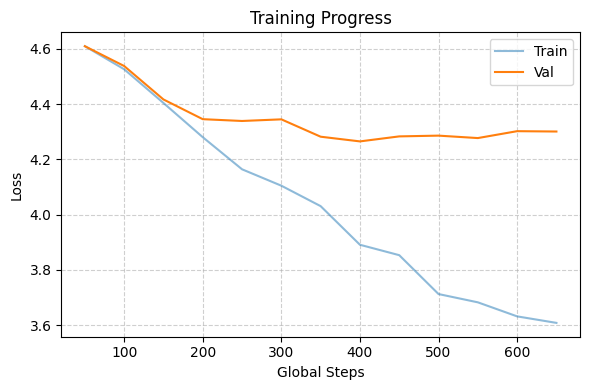

In [34]:
plot_training_results(train_losses3, val_losses3, 50, title="Training Progress")

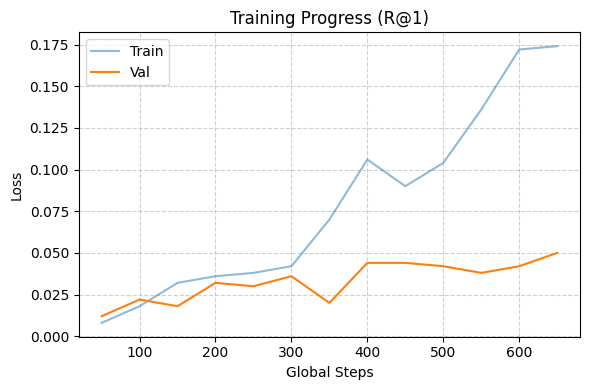

In [35]:
plot_training_results(train_r_at_3_lst, val_r_at_3_lst, 50, title="Training Progress (R@1)")

In [36]:
# evaluating r@1 on a batch of 100

def compute_r_at_1(model, dataloader, device="cuda"):
    model.eval()

    total = 0
    i2t_correct = 0
    t2i_correct = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating R@1"):
            images = batch[0].to(device)
            tokens = {k: v.to(device) for k, v in batch[1].items()}

            logits = model(images, tokens)  # (B, B)

            B = logits.size(0)
            gt = torch.arange(B).to(device)

            # Image → Text
            i2t_preds = logits.argmax(dim=1)
            i2t_correct += (i2t_preds == gt).sum().item()

            # Text → Image
            t2i_preds = logits.argmax(dim=0)
            t2i_correct += (t2i_preds == gt).sum().item()

            total += B

    i2t_r1 = i2t_correct / total
    t2i_r1 = t2i_correct / total

    return {
        "i2t_r@1": i2t_r1,
        "t2i_r@1": t2i_r1,
        "mean_r@1": (i2t_r1 + t2i_r1) / 2
    }

model = CLIP3(vit, gpt, emb_dim=256)
model.load_state_dict(torch.load("/content/drive/My Drive/clip_vit_gpt_scratch.pth", weights_only=False))
model.to(device)

metrics = compute_r_at_1(model, val_loader3, device)
print()
print(metrics)

Evaluating R@1: 100%|██████████| 17/17 [00:14<00:00,  1.15it/s]


{'i2t_r@1': 0.05003088326127239, 't2i_r@1': 0.044471896232242125, 'mean_r@1': 0.04725138974675726}


#### Visualizing Embeddings

In [37]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_embeddings(model, dataloader, device="cuda"):
    model.eval()

    all_img_embs = []
    all_text_embs = []

    with torch.no_grad():
        for imgs, tokens in dataloader:
            imgs = imgs.to(device)
            tokens = {k: v.to(device) for k, v in tokens.items()}

            # ---- IMAGE ----
            img_features = model.image_encoder(imgs)
            img_emb = model.img_proj(img_features)
            img_emb = img_emb / torch.linalg.norm(img_emb, dim=-1, keepdim=True)

            # ---- TEXT ----
            logits = model.text_encoder(tokens["tokens"])
            last_token_idx = tokens["masks"].sum(1) - 1
            last_token_idx = last_token_idx.unsqueeze(1).unsqueeze(2)
            last_token_idx = last_token_idx.expand(-1, 1, logits.size(-1))
            text_features = torch.gather(logits, dim=1, index=last_token_idx).squeeze(1)
            text_emb = model.text_proj(text_features)
            text_emb = text_emb / torch.linalg.norm(text_emb, dim=-1, keepdim=True)

            all_img_embs.append(img_emb.cpu())
            all_text_embs.append(text_emb.cpu())

    all_img_embs = torch.cat(all_img_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    return all_img_embs, all_text_embs


def plot_tsne(img_embs, text_embs):
    # Combine
    X = torch.cat([img_embs, text_embs], dim=0).numpy()

    # Labels: 0 = image, 1 = text
    labels = [0]*len(img_embs) + [1]*len(text_embs)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    # # Split back
    # img_2d = X_2d[:len(img_embs)]
    # text_2d = X_2d[len(img_embs):]

    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.scatter(img_2d[:, 0], img_2d[:, 1], label="Image", alpha=0.7)
    # plt.scatter(text_2d[:, 0], text_2d[:, 1], label="Text", alpha=0.7)

    colors = list(range(len(img_embs))) + list(range(len(text_embs)))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='tab20')

    plt.legend()
    plt.title("t-SNE of Image & Text Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

/tmp/ipykernel_2307/3232071089.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


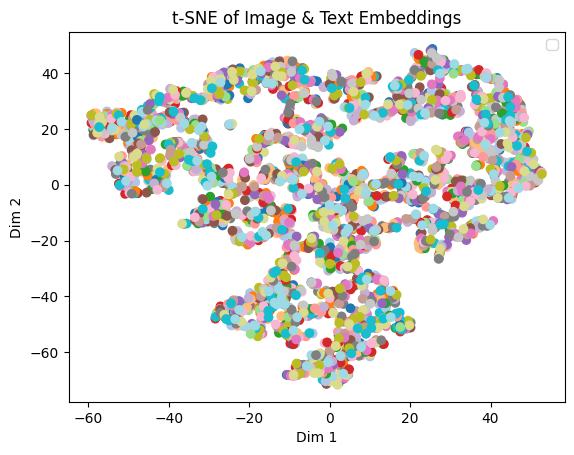

In [38]:
img_embs, text_embs = get_embeddings(model3, val_loader3, device=device)
plot_tsne(img_embs, text_embs)